In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load dataset
df = pd.read_csv('../data/apple_sales.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (11500, 27)

Columns: ['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region', 'city', 'product_name', 'category', 'storage', 'color', 'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd', 'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency', 'sales_channel', 'payment_method', 'customer_segment', 'customer_age_group', 'previous_device_os', 'customer_rating', 'return_status']

First 3 rows:


,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,storage,color,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,NaN,Starlight,159.27,7,1,148.12,148.12,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,NaN,Black,29.99,15,5,25.49,127.45,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,NaN,Titanium,293.92,0,4,293.92,1175.68,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept


In [3]:
# Data types and missing values
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

=== DATA TYPES ===
sale_id                    object
sale_date                  object
year                        int64
quarter                    object
month                      object
country                    object
region                     object
city                       object
product_name               object
category                   object
storage                    object
color                      object
unit_price_usd            float64
discount_pct                int64
units_sold                  int64
discounted_price_usd      float64
revenue_usd               float64
currency                   object
fx_rate_to_usd            float64
revenue_local_currency    float64
sales_channel              object
payment_method             object
customer_segment           object
customer_age_group         object
previous_device_os         object
customer_rating           float64
return_status              object
dtype: object

=== MISSING VALUES ===
                    Missi

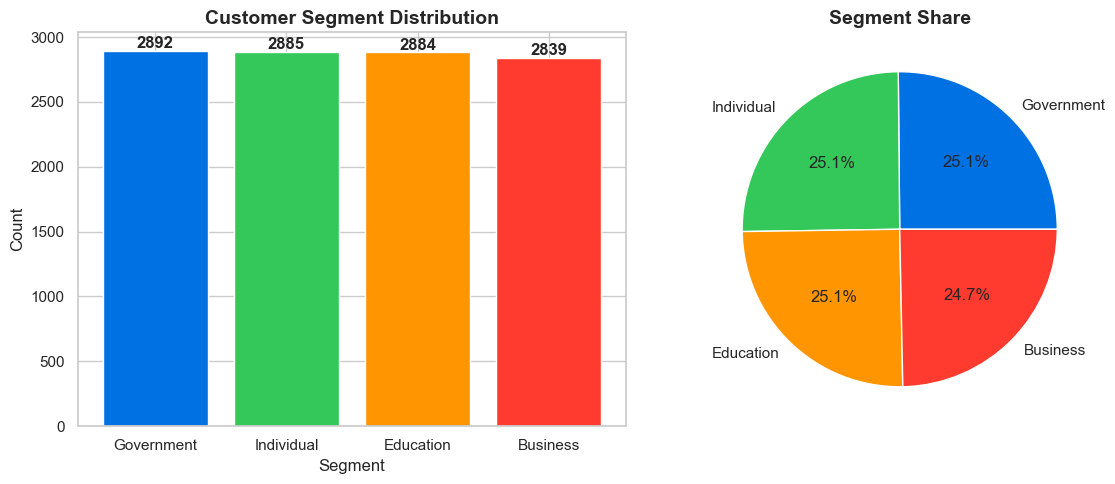

customer_segment
Government    2892
Individual    2885
Education     2884
Business      2839
Name: count, dtype: int64


In [4]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
segment_counts = df['customer_segment'].value_counts()
axes[0].bar(segment_counts.index, segment_counts.values, 
            color=['#0071e3', '#34c759', '#ff9500', '#ff3b30'])
axes[0].set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Count')
for i, v in enumerate(segment_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
            colors=['#0071e3', '#34c759', '#ff9500', '#ff3b30'])
axes[1].set_title('Segment Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(segment_counts)

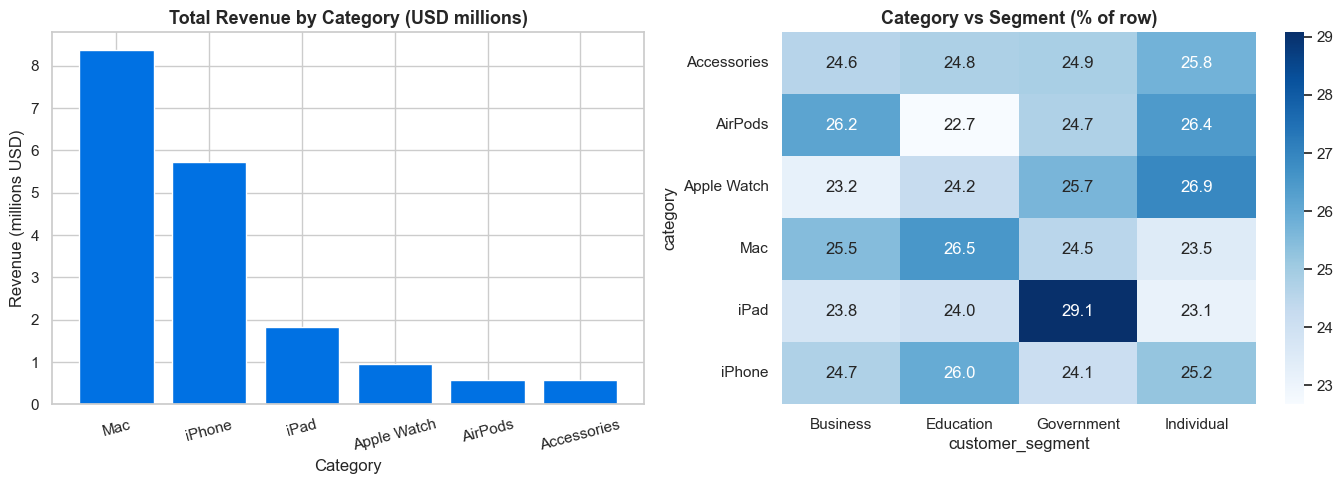

In [5]:
# Sales by category and segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by category
revenue_by_cat = df.groupby('category')['revenue_usd'].sum().sort_values(ascending=False)
axes[0].bar(revenue_by_cat.index, revenue_by_cat.values / 1e6, color='#0071e3')
axes[0].set_title('Total Revenue by Category (USD millions)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Revenue (millions USD)')
axes[0].tick_params(axis='x', rotation=15)

# Category by segment heatmap
cat_seg = pd.crosstab(df['category'], df['customer_segment'], normalize='index') * 100
sns.heatmap(cat_seg, annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set_title('Category vs Segment (% of row)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

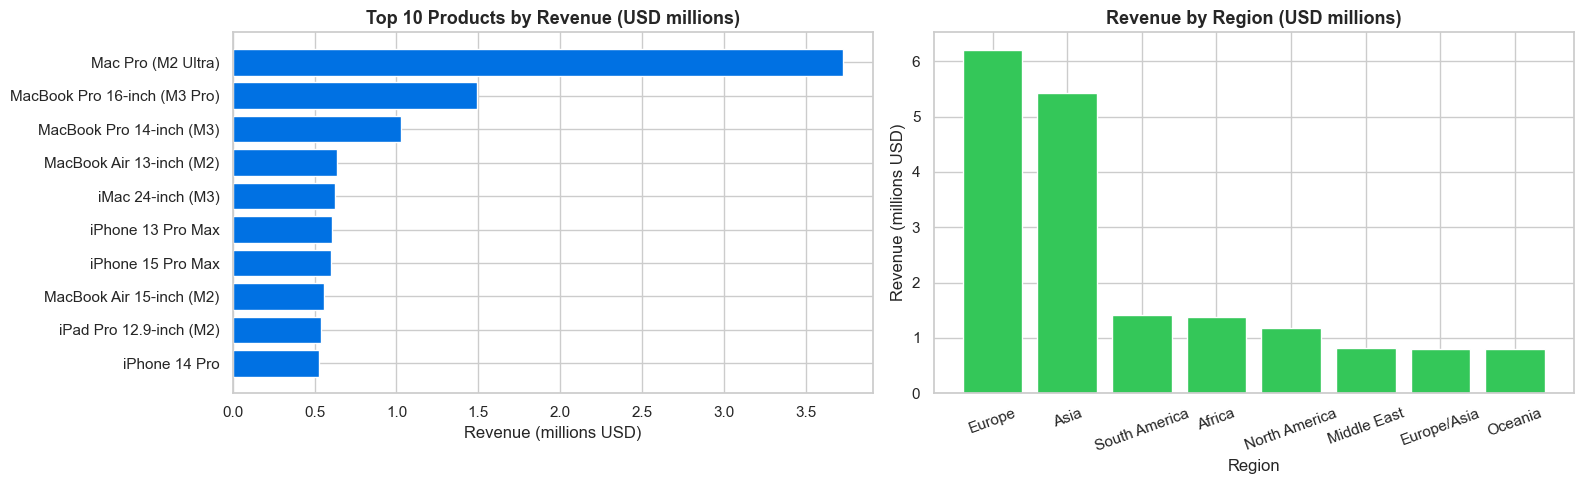

In [6]:
# Top 10 products by revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_products = df.groupby('product_name')['revenue_usd'].sum().sort_values(ascending=False).head(10)
axes[0].barh(top_products.index, top_products.values / 1e6, color='#0071e3')
axes[0].set_title('Top 10 Products by Revenue (USD millions)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (millions USD)')
axes[0].invert_yaxis()

# Revenue by region
revenue_by_region = df.groupby('region')['revenue_usd'].sum().sort_values(ascending=False)
axes[1].bar(revenue_by_region.index, revenue_by_region.values / 1e6, color='#34c759')
axes[1].set_title('Revenue by Region (USD millions)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Revenue (millions USD)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('products_regions.png', dpi=150, bbox_inches='tight')
plt.show()

=== KPIs BY SEGMENT ===
                  Revenue (M$)  Avg Order ($)  Units Sold  Avg Rating  \
customer_segment                                                        
Business                  4.46        1569.48        5771        4.01   
Education                 4.64        1607.42        5760        4.01   
Government                4.49        1553.75        5882        3.99   
Individual                4.45        1542.70        5857        4.00   

                  Return Rate (%)  
customer_segment                   
Business                     8.10  
Education                    8.39  
Government                   7.09  
Individual                   7.66  


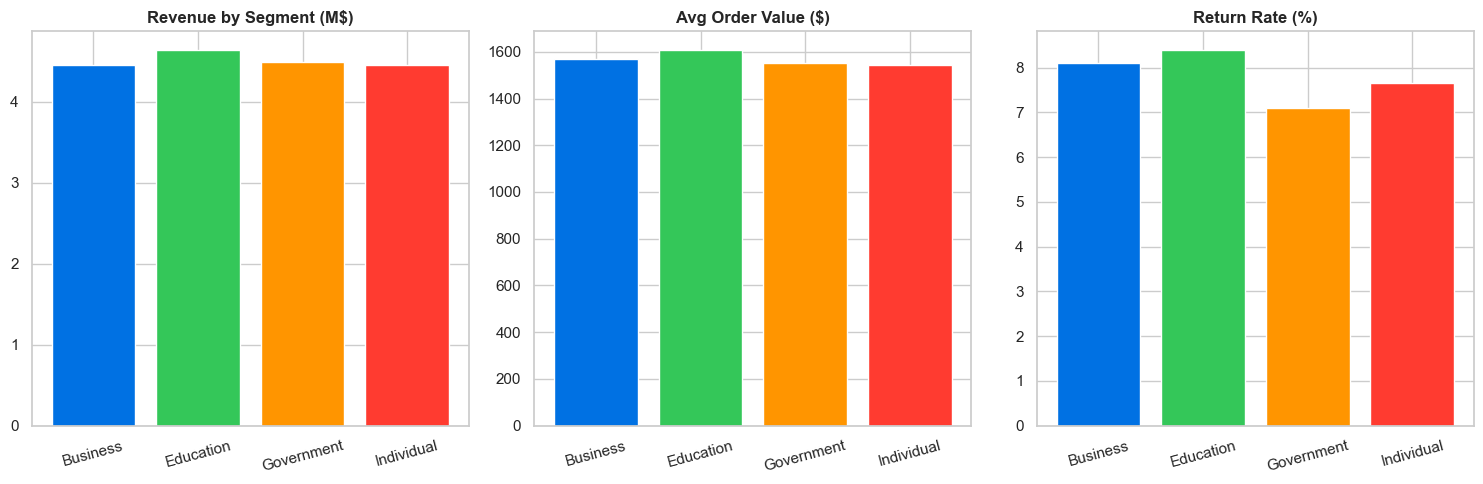

In [7]:
# Key KPIs per segment
kpis = df.groupby('customer_segment').agg(
    total_revenue=('revenue_usd', 'sum'),
    avg_order_value=('revenue_usd', 'mean'),
    total_units=('units_sold', 'sum'),
    avg_rating=('customer_rating', 'mean'),
    return_rate=('return_status', lambda x: (x == 'Returned').mean() * 100)
).round(2)

kpis['total_revenue_M'] = (kpis['total_revenue'] / 1e6).round(2)

print("=== KPIs BY SEGMENT ===")
print(kpis[['total_revenue_M', 'avg_order_value', 'total_units', 'avg_rating', 'return_rate']]
      .rename(columns={
          'total_revenue_M': 'Revenue (M$)',
          'avg_order_value': 'Avg Order ($)',
          'total_units': 'Units Sold',
          'avg_rating': 'Avg Rating',
          'return_rate': 'Return Rate (%)'
      }))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#0071e3', '#34c759', '#ff9500', '#ff3b30']

axes[0].bar(kpis.index, kpis['total_revenue_M'], color=colors)
axes[0].set_title('Revenue by Segment (M$)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(kpis.index, kpis['avg_order_value'], color=colors)
axes[1].set_title('Avg Order Value ($)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(kpis.index, kpis['return_rate'], color=colors)
axes[2].set_title('Return Rate (%)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('kpis_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

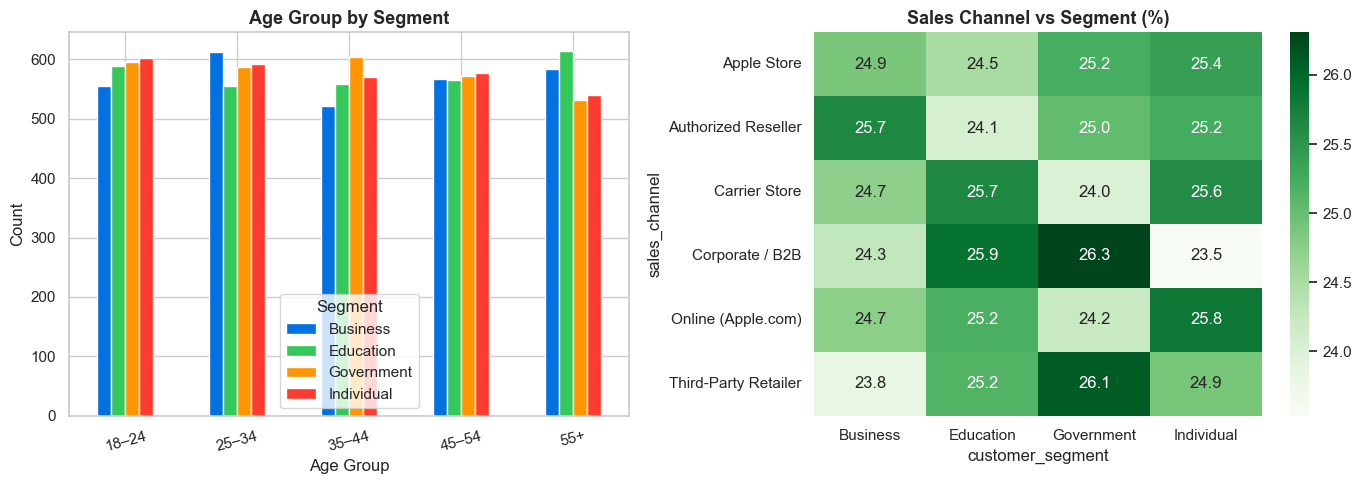

In [8]:
# Age group distribution by segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_seg = pd.crosstab(df['customer_age_group'], df['customer_segment'])
age_seg.plot(kind='bar', ax=axes[0], color=['#0071e3', '#34c759', '#ff9500', '#ff3b30'])
axes[0].set_title('Age Group by Segment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Segment')

# Sales channel by segment
channel_seg = pd.crosstab(df['sales_channel'], df['customer_segment'], normalize='index') * 100
sns.heatmap(channel_seg, annot=True, fmt='.1f', cmap='Greens', ax=axes[1])
axes[1].set_title('Sales Channel vs Segment (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('age_channel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Summary
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total records:       {len(df):,}")
print(f"Date range:          {df['sale_date'].min()} → {df['sale_date'].max()}")
print(f"Countries:           {df['country'].nunique()}")
print(f"Products:            {df['product_name'].nunique()}")
print(f"Total revenue:       ${df['revenue_usd'].sum()/1e6:.1f}M")
print(f"Avg order value:     ${df['revenue_usd'].mean():.2f}")
print()
print("=" * 50)
print("KEY FINDINGS")
print("=" * 50)
print("1. Dataset is perfectly balanced (~25% per segment)")
print("2. No significant difference in revenue across segments")
print("3. sales_channel and payment_method are uniform across segments")
print("4. Target variable appears randomly assigned (synthetic data)")
print("5. Model features: product_name, category, color,")
print("   customer_age_group, region, country, city")
print()
print("=" * 50)
print("MODEL FEATURES SELECTED")
print("=" * 50)
features = ['product_name', 'category', 'color', 
            'customer_age_group', 'region', 'country', 'city']
for f in features:
    print(f"  ✓ {f} ({df[f].nunique()} unique values)")

DATASET SUMMARY
Total records:       11,500
Date range:          2022-01-01 → 2024-12-31
Countries:           47
Products:            43
Total revenue:       $18.0M
Avg order value:     $1568.32

KEY FINDINGS
1. Dataset is perfectly balanced (~25% per segment)
2. No significant difference in revenue across segments
3. sales_channel and payment_method are uniform across segments
4. Target variable appears randomly assigned (synthetic data)
5. Model features: product_name, category, color,
   customer_age_group, region, country, city

MODEL FEATURES SELECTED
  ✓ product_name (43 unique values)
  ✓ category (6 unique values)
  ✓ color (20 unique values)
  ✓ customer_age_group (5 unique values)
  ✓ region (8 unique values)
  ✓ country (47 unique values)
  ✓ city (514 unique values)
